# 03 · Results

Charts of the out-of-sample backtest. Everything comes from `results/<stage>/test_orders.csv`,
written once by `scripts/backtest.py`; the tables are the same ones `scripts/report.py`
writes to `summary.md`. Δ vs VWAP is each strategy's implementation shortfall minus VWAP's
on the same parent order: **below zero = cheaper than VWAP**. Intervals are 95% block-bootstrap
intervals.

In [1]:
import os
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from adaptive_exec.pipeline import load_config
from adaptive_exec.plotting import (AXIS, INK_2, SERIES, SURFACE, DIVERGING, apply_style,
                                    ci_dots, small_multiples, zero_line)

CONFIG = os.environ.get("ADAPTIVE_EXEC_CONFIG", "configs/stage1_itch.yaml")
cfg = load_config(CONFIG)
apply_style()
pd.set_option("display.width", 160, "display.max_columns", 30)
print(f"config: {CONFIG} | stage: {cfg['stage']} | symbols: {', '.join(cfg['symbols'])}")

config: configs/stage1_itch.yaml | stage: stage1_itch | symbols: AAPL, AMZN, GOOG, INTC, MSFT


In [2]:
from adaptive_exec.reporting import (ADAPTIVE, COST_PARTS, FAMILIES, MAIN_KINDS, ci,
                                    decomposition_table, load_test_orders, main_table, primary,
                                    success)

assert (Path(cfg["results_dir"]) / "test_orders.csv").exists(), "run scripts/backtest.py first"
d_all = load_test_orders(cfg)
d_main = d_all[d_all["kind"].isin(MAIN_KINDS)]
prim = primary(d_main, cfg)
t = cfg["tuning"]
display(Markdown(f"**Main table, {t['impact']} impact, {t['fill_mode']} fills**\n\n" + main_table(prim, cfg)))
display(Markdown(success(d_main, cfg)[0]))

**Main table, medium impact, conservative fills**

| Strategy | Mean IS (bps) | Median | Std. dev. | 95th pct | Δ vs VWAP (95% CI) | Share filled passively |
|---|---|---|---|---|---|---|
| TWAP | 3.78 | 3.33 | 14.73 | 27.63 | -0.04 [-0.17, +0.11] | 54.1% |
| VWAP | 3.82 | 3.60 | 15.11 | 29.12 | baseline | 54.3% |
| Almgren-Chriss | 3.78 | 3.78 | 13.01 | 24.77 | -0.05 [-0.17, +0.10] | 53.8% |
| Heuristic adaptive | 3.97 | 3.78 | 14.85 | 28.46 | +0.15 [+0.04, +0.28] | 40.4% |
| ML adaptive (tactic only) | 3.78 | 3.65 | 14.92 | 28.48 | -0.04 [-0.14, +0.08] | 41.2% |
| ML adaptive (tactic + speed) | 3.85 | 3.65 | 14.69 | 28.21 | +0.02 [-0.14, +0.20] | 29.7% |

**ML adaptive (tactic only): not shown to be better than VWAP** (Δ -0.04 [-0.14, +0.08] bps)

- [ ] 95% CI of Δ vs VWAP excludes zero, below it (medium impact, conservative fills)
- [x] direction holds for buys
- [ ] direction holds for sells
- [x] direction holds at none impact
- [x] direction holds at strong impact

**ML adaptive (tactic + speed): not shown to be better than VWAP** (Δ +0.02 [-0.14, +0.20] bps)

- [ ] 95% CI of Δ vs VWAP excludes zero, below it (medium impact, conservative fills)
- [ ] direction holds for buys
- [x] direction holds for sells
- [x] direction holds at none impact
- [ ] direction holds at strong impact

## Δ vs VWAP by strategy

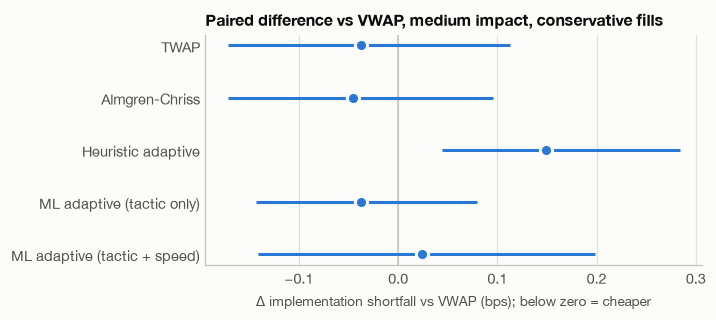

,delta_bps,lo,hi
TWAP,-0.037,-0.171,0.113
Almgren-Chriss,-0.046,-0.172,0.096
Heuristic adaptive,0.149,0.044,0.284
ML adaptive (tactic only),-0.037,-0.144,0.079
ML adaptive (tactic + speed),0.024,-0.141,0.198


In [3]:
names = [s for s in FAMILIES if s != "VWAP"]
est = pd.DataFrame([ci(prim[prim["strategy"] == s], cfg) for s in names], index=names,
                   columns=["delta_bps", "lo", "hi"])
fig, ax = plt.subplots(figsize=(6.4, 2.8), layout="constrained")
ci_dots(ax, est.index, est["delta_bps"], est["lo"], est["hi"])
ax.set_xlabel("Δ implementation shortfall vs VWAP (bps); below zero = cheaper")
ax.set_title(f"Paired difference vs VWAP, {t['impact']} impact, {t['fill_mode']} fills")
plt.show()
est.round(3)

## Where the cost comes from

Mean cost per component, in bps of arrival notional. Resting fills earn the spread (negative) but can pay in drift (adverse selection).

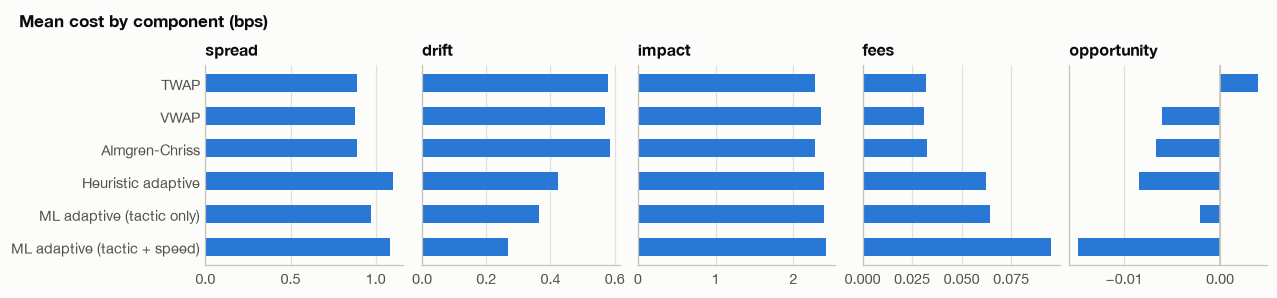

,spread_bps,drift_bps,impact_bps,fees_bps,opportunity_bps,is_bps
strategy,,,,,,
TWAP,0.887,0.580,2.282,0.032,0.004,3.785
VWAP,0.877,0.571,2.350,0.031,-0.006,3.822
Almgren-Chriss,0.889,0.586,2.276,0.032,-0.007,3.776
Heuristic adaptive,1.105,0.425,2.388,0.062,-0.008,3.971
ML adaptive (tactic only),0.973,0.363,2.387,0.064,-0.002,3.785
ML adaptive (tactic + speed),1.081,0.266,2.418,0.095,-0.015,3.846


In [4]:
g = prim.groupby("strategy")[COST_PARTS + ["is_bps"]].mean().reindex(FAMILIES)
fig, axes = small_multiples(len(COST_PARTS), ncols=5, sharex=False, sharey=True, panel=(2.3, 2.6))
for ax, part in zip(axes, COST_PARTS):
    ax.barh(g.index[::-1], g[part].to_numpy()[::-1], height=0.55, color=SERIES[0])
    zero_line(ax, "x")
    ax.grid(axis="y", visible=False)
    ax.set_title(part.replace("_bps", ""))
fig.suptitle("Mean cost by component (bps)", x=0.01, ha="left", fontweight="semibold")
plt.show()
g.round(3)

## Robustness: impact setting and fill assumption

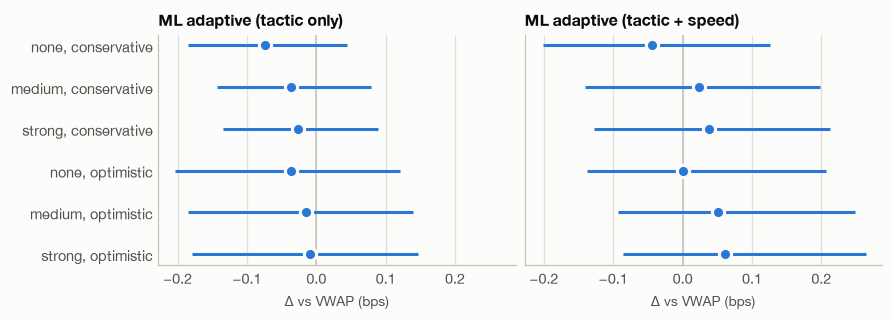

,strategy,impact,fills,delta_bps,lo,hi
0,ML adaptive (tactic only),none,conservative,-0.075,-0.185,0.045
1,ML adaptive (tactic only),medium,conservative,-0.037,-0.144,0.079
2,ML adaptive (tactic only),strong,conservative,-0.027,-0.135,0.089
3,ML adaptive (tactic only),none,optimistic,-0.036,-0.204,0.121
4,ML adaptive (tactic only),medium,optimistic,-0.015,-0.185,0.140
5,ML adaptive (tactic only),strong,optimistic,-0.008,-0.179,0.147
6,ML adaptive (tactic + speed),none,conservative,-0.044,-0.201,0.126
7,ML adaptive (tactic + speed),medium,conservative,0.024,-0.141,0.198
8,ML adaptive (tactic + speed),strong,conservative,0.037,-0.128,0.212
9,ML adaptive (tactic + speed),none,optimistic,0.000,-0.138,0.206


In [5]:
ml = ["ML adaptive (tactic only)", "ML adaptive (tactic + speed)"]
fig, axes = small_multiples(len(ml), ncols=2, sharex=True, sharey=True, panel=(4.0, 2.8))
rows = []
for ax, s in zip(axes, ml):
    labels, est = [], []
    for fill in cfg["fill_modes"]:
        for imp in cfg["impact"]:
            x = d_main[(d_main["strategy"] == s) & (d_main["impact"] == imp) & (d_main["fill_mode"] == fill)]
            labels.append(f"{imp}, {fill}")
            est.append(ci(x, cfg))
            rows.append({"strategy": s, "impact": imp, "fills": fill, **dict(zip(["delta_bps", "lo", "hi"], est[-1]))})
    e = np.array(est)
    ci_dots(ax, labels, e[:, 0], e[:, 1], e[:, 2])
    ax.set_title(s)
    ax.set_xlabel("Δ vs VWAP (bps)")
plt.show()
pd.DataFrame(rows).round(3)

## Leave-one-stock-out (Stage 1 only)

The same test orders, with the model and thresholds chosen on the *other* stocks versus on the same stock.

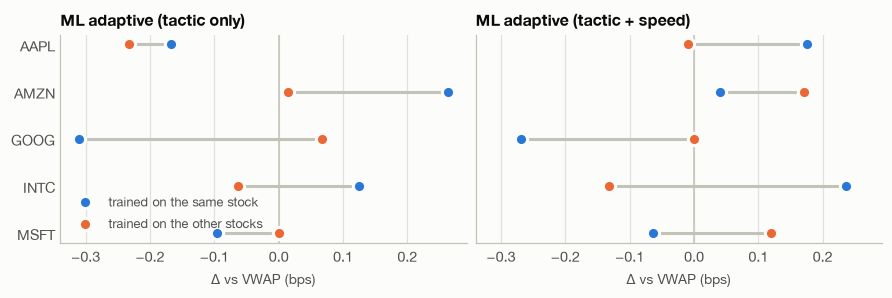

,strategy,stock,same_stock,other_stocks
0,ML adaptive (tactic only),AAPL,-0.168,-0.233
1,ML adaptive (tactic only),AMZN,0.263,0.014
2,ML adaptive (tactic only),GOOG,-0.311,0.067
3,ML adaptive (tactic only),INTC,0.125,-0.064
4,ML adaptive (tactic only),MSFT,-0.095,0.000
5,ML adaptive (tactic + speed),AAPL,0.176,-0.010
6,ML adaptive (tactic + speed),AMZN,0.041,0.170
7,ML adaptive (tactic + speed),GOOG,-0.269,0.000
8,ML adaptive (tactic + speed),INTC,0.236,-0.133
9,ML adaptive (tactic + speed),MSFT,-0.064,0.120


In [6]:
loso = primary(d_all[d_all["kind"] == "loso"], cfg)
if loso.empty:
    print("no leave-one-stock-out units in this config")
else:
    own = prim[prim["kind"] == "per_stock"]
    syms = sorted(loso["symbol"].unique())
    fig, axes = small_multiples(len(ml), ncols=2, sharex=True, sharey=True, panel=(4.0, 2.6))
    rows = []
    for ax, s in zip(axes, ml):
        a = [ci(loso[(loso["strategy"] == s) & (loso["symbol"] == y)], cfg)[0] for y in syms]
        b = [ci(own[(own["strategy"] == s) & (own["symbol"] == y)], cfg)[0] for y in syms]
        yy = np.arange(len(syms))[::-1]
        ax.hlines(yy, np.minimum(a, b), np.maximum(a, b), color=AXIS, linewidth=2, zorder=1)
        ax.plot(b, yy, "o", color=SERIES[0], label="trained on the same stock", zorder=3)
        ax.plot(a, yy, "o", color=SERIES[1], label="trained on the other stocks", zorder=3)
        ax.set_yticks(yy, syms)
        ax.grid(axis="y", visible=False)
        zero_line(ax, "x")
        ax.set_title(s)
        ax.set_xlabel("Δ vs VWAP (bps)")
        rows += [{"strategy": s, "stock": y, "same_stock": bb, "other_stocks": aa} for y, aa, bb in zip(syms, a, b)]
    axes[0].legend(loc="lower left", fontsize=8.5)
    plt.show()
    display(pd.DataFrame(rows).round(3))